In [63]:
# ----------------
# Set up
# ----------------

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load and view data
df = pd.read_csv(r"C:\Users\naomi\OneDrive\Desktop\Career\Projects\BMW Project\bmw_dataset.csv")
print("Dataset info")
print(df.head())
print(df.info())
print(df.describe())

# Convert units (1 GDP =~ 1.85 CAD, 1 mile =~ 1.61 km, and MPG to L/100km)
df["price_cad"] = df["price"] * 1.85
df["mileage_km"] = df["mileage"] * 1.61
df['fuel_consumption'] = 235.215 / df['mpg']

# New variables
df["car_age"] = 2026 - df["year"]
df["price_per_km"] = np.where(df["mileage_km"] > 0, df["price_cad"] / df["mileage_km"], np.nan)

# Check category values
print()
print("Categories")
print("Transmissions: ", df["transmission"].unique())
print("Fuel types: ", df["fuelType"].unique())
print("Models: ", df["model"].unique())

# Flag unrealistic fuel consumption values
fuel_consumption_outliers = df[(df["fuel_consumption"] <= 2) |
                                 (df["fuel_consumption"] >= 25)]
print()
print("Fuel consumption outliers: ")
print(fuel_consumption_outliers)
          
# Remove unrealistic fuel consumption values
df = df[(df["fuel_consumption"] > 2) &
        (df["fuel_consumption"] < 25)]

# Remove impossible values
df = df[df["price_cad"] > 0]
df = df[df["mileage_km"] >= 0]
df = df[df["car_age"] >= 0]

Dataset info
       model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax    

In [80]:
# -------------------------
# Data exploration
# -------------------------
print("Number of listings by BMW model: ")
print(df["model"].value_counts())
print()

print("Average vehicle price: ", df["price_cad"].mean())
print()

print("Average price per model (CAD): ")
print(df.groupby("model")["price_cad"].mean().sort_values(ascending = False))
print()

print("Average mileage by model (km): ")
print(df.groupby("model")["mileage_km"].mean().sort_values(ascending = False))
print()

print("Average price by transmission (CAD): ")
print(df.groupby("transmission")["price_cad"].mean().sort_values(ascending = False))
print()

print("Average price by fuel type (CAD): ")
print(df.groupby("fuelType")["price_cad"].mean().sort_values(ascending = False))

Number of listings by BMW model: 
model
 3 Series    2332
 1 Series    1969
 2 Series    1199
 5 Series    1005
 4 Series     995
 X1           804
 X3           545
 X5           463
 X2           288
 X4           179
 M4           125
 6 Series     108
 Z4           108
 X6           106
 7 Series     105
 X7            55
 8 Series      39
 M5            29
 M3            27
 M2            21
 M6             8
 Z3             7
Name: count, dtype: int64

Average vehicle price:  41948.998378815246

Average price per model (CAD): 
model
 X7          129209.112727
 8 Series    118395.920513
 M5          106856.000000
 X6           81101.434434
 M4           80057.329200
 M2           79809.616667
 X5           72768.451404
 7 Series     68380.193333
 X4           60534.470112
 M6           59551.500000
 M3           55925.088889
 X2           52700.326910
 X3           50883.326697
 Z4           49953.580093
 6 Series     45055.585185
 4 Series     41622.073467
 5 Series     40942.134

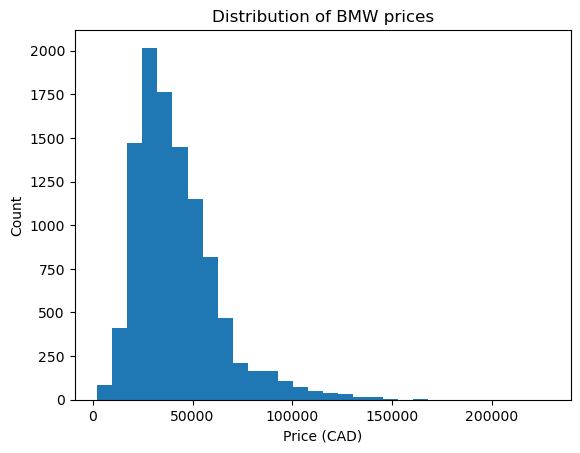

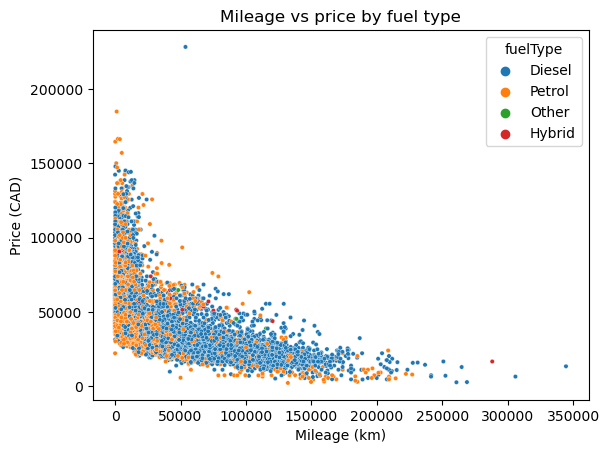

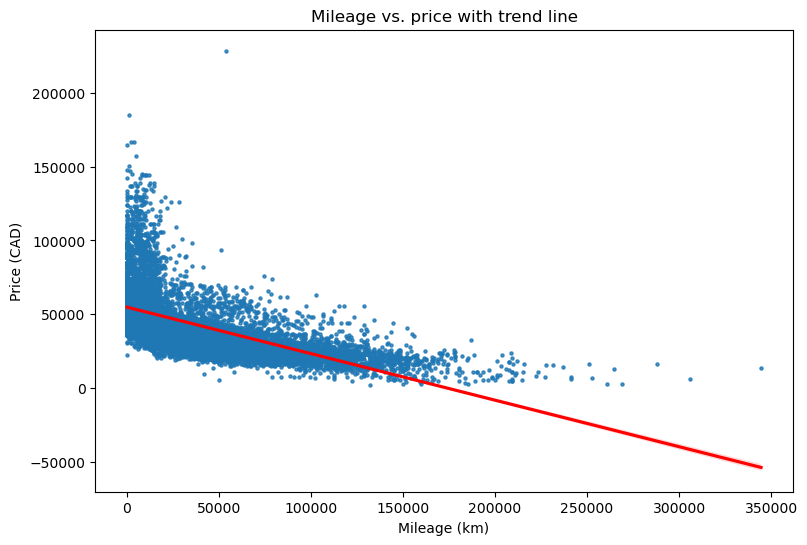

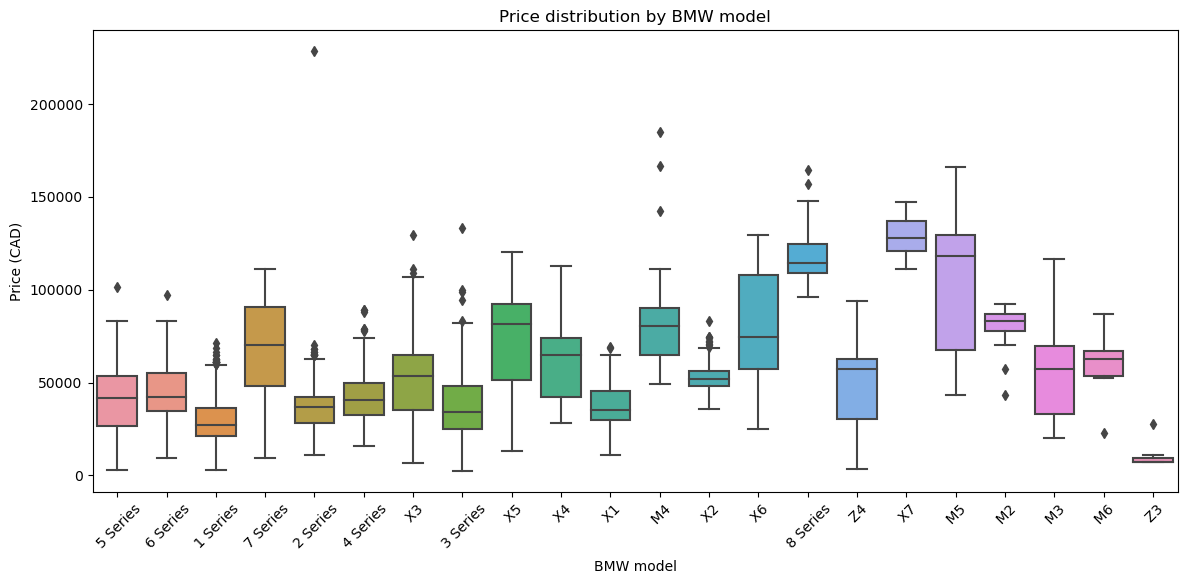

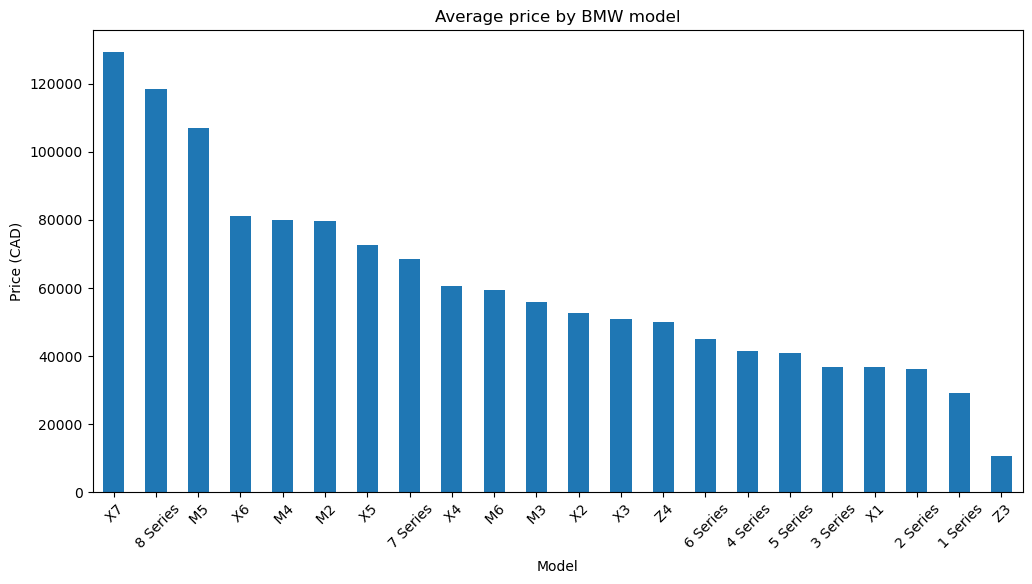

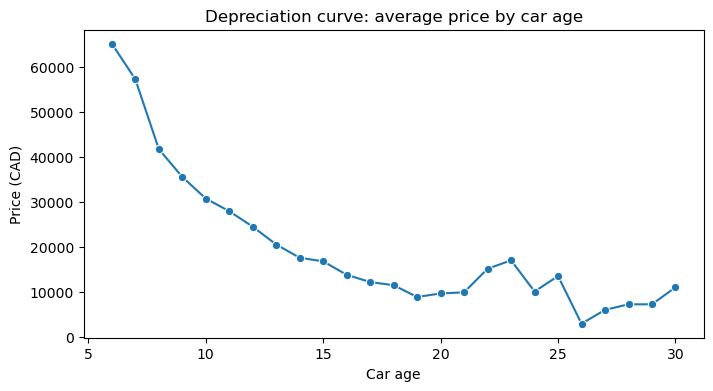

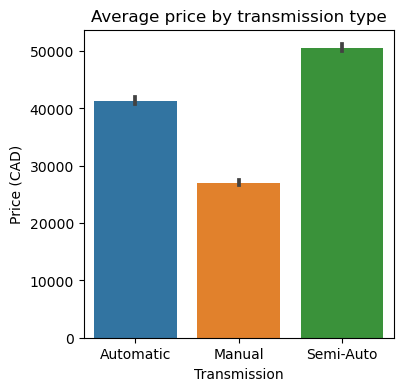

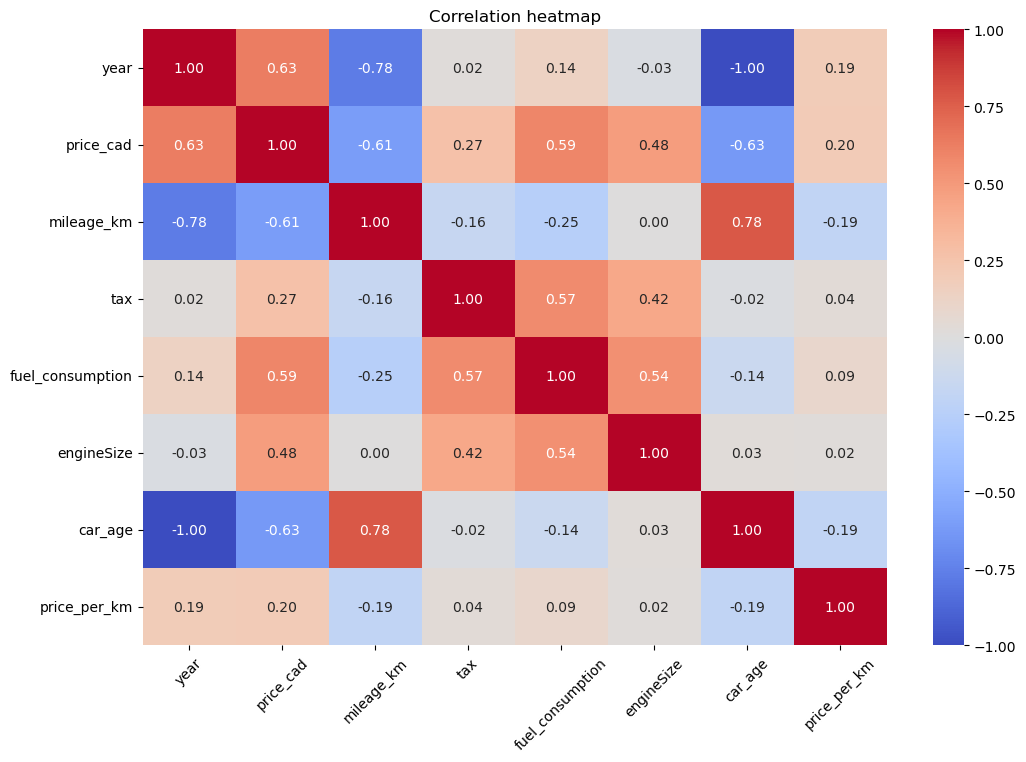

In [111]:
#-------------------------------
# Exploratory data visualization
# ------------------------------

# Price distribution
plt.hist(df["price_cad"], bins = 30)
plt.xlabel("Price (CAD)")
plt.ylabel("Count")
plt.title("Distribution of BMW prices")
plt.show()
print()

# Mileage vs. price 
sns.scatterplot(x = "mileage_km",
                y = "price_cad",
                data = df,
                hue = "fuelType",
                s = 10)
plt.xlabel("Mileage (km)")
plt.ylabel("Price (CAD)")
plt.title("Mileage vs price by fuel type")
plt.show()
print()

# Mileage vs. price with linear regression
plt.figure(figsize = (9,6))
sns.regplot(x = "mileage_km",
            y = "price_cad",
            data = df,
            scatter_kws = {"s": 5},
            line_kws = {"color": "red"})
plt.xlabel("Mileage (km)")
plt.ylabel("Price (CAD)")
plt.title("Mileage vs. price with trend line")
plt.show()
print()

# Price by model
plt.figure(figsize = (14, 6))
sns.boxplot(x = "model",
            y = "price_cad",
            data = df)
plt.xticks(rotation = 45)
plt.xlabel("BMW model")
plt.ylabel("Price (CAD)")
plt.title("Price distribution by BMW model")
plt.show()
print()

# Average price by model
avg_price_model = (df.groupby("model")["price_cad"].mean().sort_values(ascending=False))
plt.figure(figsize = (12, 6))
avg_price_model.plot(kind = "bar")
plt.ylabel("Price (CAD)")
plt.xlabel("Model")
plt.title("Average price by BMW model")
plt.xticks(rotation = 45)
plt.show()
print()

# Depreciation curve: average price by car age
avg_price_age = (df.groupby("car_age")["price_cad"].mean().reset_index())
plt.figure(figsize = (8, 4))
sns.lineplot(x = "car_age",
             y = "price_cad",
             data = avg_price_age,
             marker = "o")
plt.xlabel("Car age")
plt.ylabel("Price (CAD)")
plt.title("Depreciation curve: average price by car age")
plt.show()
print()

# Average price by transmission
plt.figure(figsize = (4, 4))
sns.barplot(x = "transmission",
            y = "price_cad",
            data = df)
plt.xlabel("Transmission")
plt.ylabel("Price (CAD)")
plt.title("Average price by transmission type")
plt.show()
print()

# Correlation heatmap
numeric_cols = ["year", "price_cad", "mileage_km", "tax", "fuel_consumption", "engineSize", "car_age", "price_per_km"]
corr = df[numeric_cols].corr()
plt.figure(figsize = (12, 8 ))
sns.heatmap(corr, 
            annot = True,
            cmap = "coolwarm",
            fmt = ".2f")
plt.xticks(rotation = 45)
plt.title("Correlation heatmap")
plt.show()

Linear regression results: 
Root mean square error (RMSE):  10374.620341857866
Mean absolute error (MAE):  7315.300068783665
Coefficient of determination (R^2):  0.7600220653162588

            Feature   Coefficient
0        mileage_km     -0.104619
1           car_age  -3820.837162
2        engineSize  13636.138360
3  fuel_consumption   6482.780297
4               tax    -43.301644



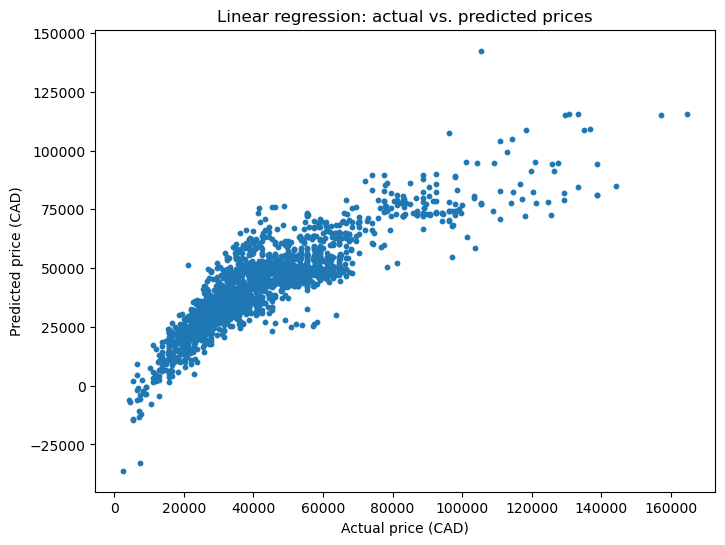

In [120]:
#-------------------------
# Linear regression model
#-------------------------

features = ["mileage_km", "car_age", "engineSize", "fuel_consumption", "tax"]
target = "price_cad"

x = df[features]
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
linear_predictions = linear_model.predict(x_test)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear regression results: ")
print("Root mean square error (RMSE): ", linear_rmse)
print("Mean absolute error (MAE): ", linear_mae)
print("Coefficient of determination (R^2): ", linear_r2)
print()

linear_coefficients = pd.DataFrame({"Feature": features, "Coefficient": linear_model.coef_})
print(linear_coefficients)
print()

plt.figure(figsize = (8, 6))
plt.scatter(y_test, linear_predictions, s = 10)
plt.xlabel("Actual price (CAD)")
plt.ylabel("Predicted price (CAD)")
plt.title("Linear regression: actual vs. predicted prices")
plt.show()

Random forest results: 
Root mean square error (RMSE): 6489.686881121441
Mean absolute error (MAE): 4049.095631470925
Coefficient of determination (R^2): 0.9060981016341573

            Feature  Importance
1           car_age    0.455595
2        engineSize    0.281965
3  fuel_consumption    0.141097
0        mileage_km    0.106042
4               tax    0.015302



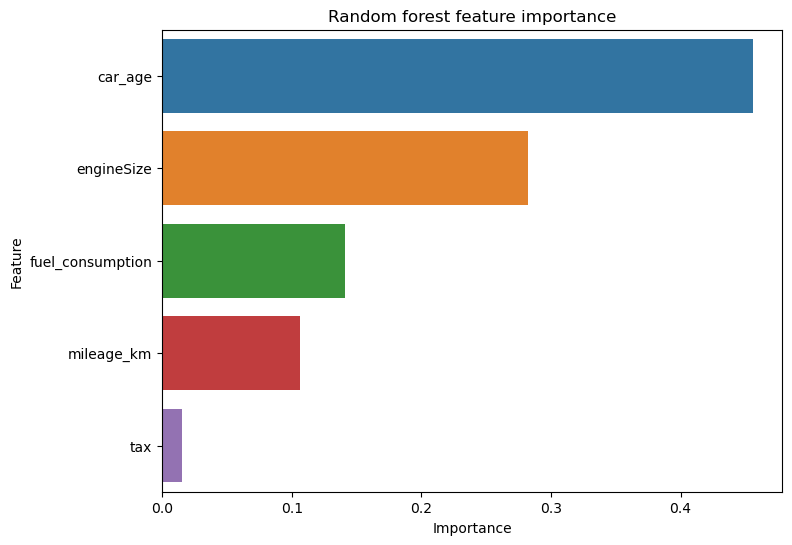

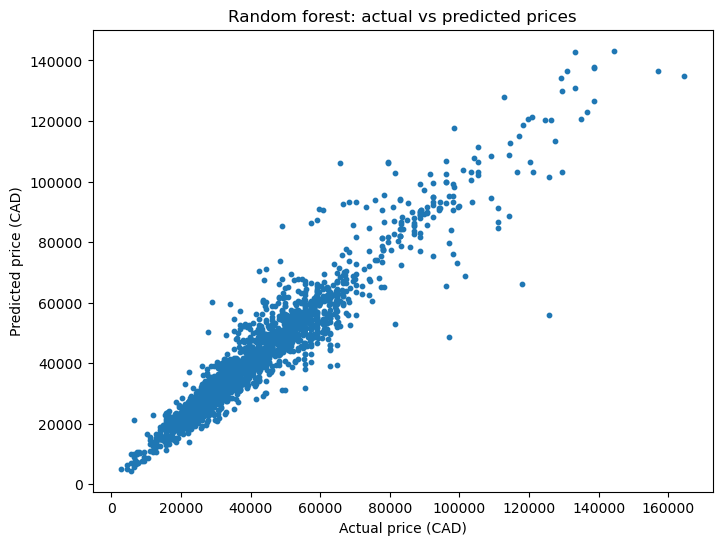

In [127]:
#--------------------
# Random forest model
#--------------------

rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_model.fit(x_train, y_train)
rf_predictions = rf_model.predict(x_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random forest results: ")
print("Root mean square error (RMSE):", rf_rmse)
print("Mean absolute error (MAE):", rf_mae)
print("Coefficient of determination (R^2):", rf_r2)
print()

feature_importance = pd.DataFrame({"Feature": features, "Importance": rf_model.feature_importances_}).sort_values(by = "Importance", ascending = False)
print(feature_importance)
print()

plt.figure(figsize = (8, 6))
sns.barplot(x = "Importance", y = "Feature", data = feature_importance)
plt.title("Random forest feature importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()
print()

plt.figure(figsize = (8, 6))
plt.scatter(y_test, rf_predictions, s = 10)
plt.xlabel("Actual price (CAD)")
plt.ylabel("Predicted price (CAD)")
plt.title("Random forest: actual vs predicted prices")
plt.show()


               Model          RMSE          MAE        R2
0  Linear regression  10374.620342  7315.300069  0.760022
1      Random forest   6489.686881  4049.095631  0.906098


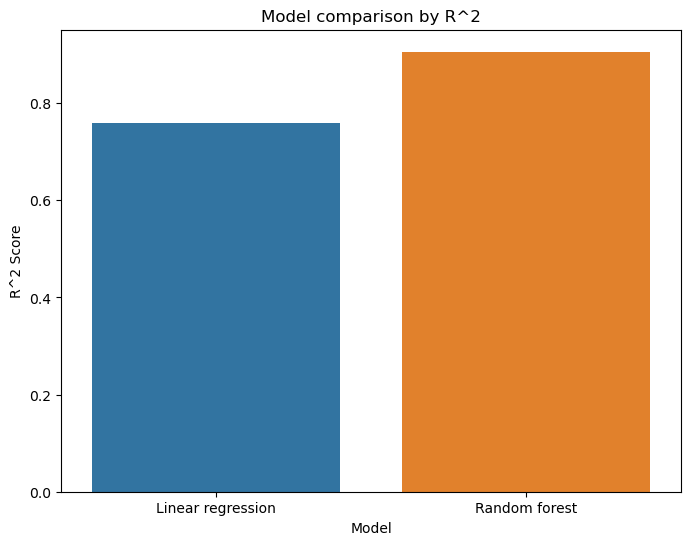

In [128]:
#------------------
# Model comparison
# -----------------

model_results = pd.DataFrame({"Model": ["Linear regression", "Random forest"], "RMSE": [linear_rmse, rf_rmse], "MAE": [linear_mae, rf_mae], "R2": [linear_r2, rf_r2]})

print(model_results)

plt.figure(figsize = (8, 6))
sns.barplot(x = "Model", y = "R2", data = model_results)
plt.title("Model comparison by R^2")
plt.ylabel("R^2 Score")
plt.show()

In [130]:
#----------------------------------
# Export clean dataset for Power BI
#----------------------------------

df.to_csv("cleaned_bmw_data.csv", index = False)

print("Cleaned dataset exported as cleaned_bmw_data.csv")

Cleaned dataset exported as cleaned_bmw_data.csv
